<a href="https://colab.research.google.com/github/MBKNgcobo/Python_projects/blob/main/FPL_MA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# INSTALL DEPENDENCIES
# ============================================================

!pip -q install -U crewai litellm google-genai ortools requests pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.2/197.2 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# ============================================================
# IMPORTS & CONFIGURATION
# ============================================================

import os
import re
import json
import math
import requests
import subprocess
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

# CrewAI
from crewai import Agent, Task, Crew, Process, LLM

# OR-Tools
from ortools.linear_solver import pywraplp

print("Environment ready.")

Environment ready.


In [ ]:
# ============================================================
# CLONE / UPDATE FPL-CORE-INSIGHTS
# ============================================================

REPO_URL = "https://github.com/olbauday/FPL-Core-Insights.git"
REPO_PATH = Path("/content/FPL-Core-Insights")

if REPO_PATH.exists():
    subprocess.run(
        ["git", "-C", str(REPO_PATH), "pull", "--quiet"],
        check=True
    )
    print("FPL-Core-Insights updated successfully.")
else:
    subprocess.run(
        ["git", "clone", "-q", REPO_URL, str(REPO_PATH)],
        check=True
    )
    print("FPL-Core-Insights cloned successfully.")

FPL-Core-Insights cloned successfully.


In [ ]:
# ============================================================
# GEMINI API CONFIGURATION
# ============================================================

from getpass import getpass

if "GEMINI_API_KEY" not in os.environ:
    os.environ["GEMINI_API_KEY"] = getpass(
        "Enter your Gemini API key: "
    )

print("Gemini API key loaded.")

Enter your Gemini API key: ··········
Gemini API key loaded.


In [ ]:
# ============================================================
# GEMINI LLM
# ============================================================

gemini_llm = LLM(
    model="gemini/gemini-3.1-flash-lite",
    api_key=os.environ["GEMINI_API_KEY"]
)

print("Gemini LLM configured.")

Gemini LLM configured.


In [ ]:
# ============================================================
# OFFICIAL FPL API
# ============================================================

FPL_BASE = "https://fantasy.premierleague.com/api"

def fpl_get(endpoint, timeout=30):
    url = f"{FPL_BASE}/{endpoint}"

    response = requests.get(
        url,
        timeout=timeout,
        headers={
            "User-Agent": "Mozilla/5.0"
        }
    )

    response.raise_for_status()
    return response.json()


bootstrap = fpl_get("bootstrap-static/")
fixtures_api = fpl_get("fixtures/")

print("FPL API connected successfully.")
print("Players:", len(bootstrap["elements"]))
print("Teams:", len(bootstrap["teams"]))
print("Fixtures:", len(fixtures_api))

FPL API connected successfully.
Players: 651
Teams: 20
Fixtures: 380


In [ ]:
# ============================================================
# CURRENT GAMEWEEK DETECTION
# ============================================================

events = pd.DataFrame(bootstrap["events"])

current_event = events[
    events["is_current"] == True
]

next_event = events[
    events["is_next"] == True
]

if not current_event.empty:
    CURRENT_GW = int(current_event.iloc[0]["id"])
    GW_STATUS = "CURRENT"
elif not next_event.empty:
    CURRENT_GW = int(next_event.iloc[0]["id"])
    GW_STATUS = "NEXT"
else:
    raise RuntimeError("Could not determine current/next Gameweek.")

print(f"Gameweek selected: GW{CURRENT_GW}")
print(f"Status: {GW_STATUS}")

Gameweek selected: GW2
Status: CURRENT


In [ ]:
# ============================================================
# LOAD FPL-CORE-INSIGHTS DATA
# ============================================================

SEASON = "2026-2027"
SEASON_PATH = REPO_PATH / "data" / SEASON

players_path = SEASON_PATH / "players.csv"
playerstats_path = SEASON_PATH / "playerstats.csv"
teams_path = SEASON_PATH / "teams.csv"

players = pd.read_csv(players_path)
playerstats = pd.read_csv(playerstats_path)
teams = pd.read_csv(teams_path)

print("Season:", SEASON)
print("Players:", players.shape)
print("Player stats:", playerstats.shape)
print("Teams:", teams.shape)

Season: 2026-2027
Players: (651, 7)
Player stats: (1267, 87)
Teams: (20, 14)


In [ ]:
# ============================================================
# LOAD LATEST COMPLETED GAMEWEEK
# ============================================================

gw_dirs = []

by_gw_path = SEASON_PATH / "By Gameweek"

for folder in by_gw_path.iterdir():
    if folder.is_dir():
        match = re.fullmatch(r"GW(\d+)", folder.name)
        if match:
            gw_dirs.append(int(match.group(1)))

gw_dirs = sorted(gw_dirs)

completed_gws = [
    gw for gw in gw_dirs
    if gw < CURRENT_GW
]

LATEST_COMPLETED_GW = max(completed_gws) if completed_gws else None

print("Current GW:", CURRENT_GW)
print("Latest completed GW:", LATEST_COMPLETED_GW)

Current GW: 2
Latest completed GW: 1


In [ ]:
# ============================================================
# FIXTURES
# ============================================================

current_gw_path = (
    SEASON_PATH /
    "By Gameweek" /
    f"GW{CURRENT_GW}" /
    "fixtures.csv"
)

if current_gw_path.exists():
    fixtures = pd.read_csv(current_gw_path)
    print("Loaded repository fixtures.")
else:
    fixtures = pd.DataFrame(fixtures_api)
    print("Loaded fixtures from official FPL API.")

print(fixtures.shape)
display(fixtures.head())

Loaded repository fixtures.
(20, 116)


,gameweek,kickoff_time,home_team,home_team_elo,home_score,away_score,away_team,away_team_elo,finished,match_id,...,home_running_distance,away_running_distance,home_sprinting_distance,away_sprinting_distance,home_number_of_sprints,away_number_of_sprints,home_top_speed,away_top_speed,bzzoiro_processed,tournament
0,2,2026-08-25T18:45:00,NaN,NaN,2.0,4.0,9.0,NaN,True,26-27-efl-cup-plymouth-argyle/exeter-city-vs-c...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,efl-cup
1,2,2026-08-26T18:45:00,6.0,NaN,5.0,1.0,NaN,NaN,True,26-27-efl-cup-tottenham-hotspur-vs-charlton-at...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,efl-cup
2,2,2026-08-25T18:45:00,NaN,NaN,1.0,1.0,88.0,NaN,True,26-27-efl-cup-stoke-city-vs-hull-city-2026-08-24,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,efl-cup
3,2,2026-08-27T19:00:00,54.0,NaN,3.0,0.0,NaN,NaN,True,26-27-efl-cup-fulham-vs-afc-bournemouth-2026-0...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,efl-cup
4,2,2026-08-30T13:00:00,2.0,1797.39,1.0,1.0,94.0,1836.59,True,26-27-prem-leeds-united-vs-brentford,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,prem


In [ ]:
# ============================================================
# MERGE PLAYER DATA
# ============================================================

live_players = pd.DataFrame(bootstrap["elements"])
live_teams = pd.DataFrame(bootstrap["teams"])

player_df = live_players.copy()

# Team mapping
team_map = live_teams.set_index("id")["name"].to_dict()

player_df["team_name"] = player_df["team"].map(team_map)

position_map = {
    1: "GK",
    2: "DEF",
    3: "MID",
    4: "FWD"
}

player_df["position"] = player_df["element_type"].map(position_map)

player_df["price"] = player_df["now_cost"] / 10

player_df["points_per_million"] = (
    player_df["total_points"] /
    player_df["price"].replace(0, np.nan)
)

print(player_df.shape)

display(
    player_df[
        [
            "id",
            "web_name",
            "team_name",
            "position",
            "price",
            "total_points",
            "form",
            "selected_by_percent"
        ]
    ].head(10)
)

(651, 113)


,id,web_name,team_name,position,price,total_points,form,selected_by_percent
0,1,Raya,Arsenal,GK,6.0,12,6.0,37.8
1,2,Arrizabalaga,Arsenal,GK,5.0,0,0.0,0.1
2,3,Meslier,Arsenal,GK,5.0,0,0.0,0.0
3,4,Gabriel,Arsenal,DEF,8.0,13,6.5,26.2
4,5,J.Timber,Arsenal,DEF,6.5,0,0.0,0.1
5,6,Saliba,Arsenal,DEF,6.0,0,0.0,0.2
6,7,Lewis-Skelly,Arsenal,MID,5.5,6,3.0,0.7
7,8,Calafiori,Arsenal,DEF,5.6,20,10.0,43.8
8,9,Hincapie,Arsenal,DEF,5.4,1,0.5,1.2
9,10,White,Arsenal,DEF,5.5,18,9.0,7.2


In [ ]:
# ============================================================
# MERGE REPOSITORY PLAYER STATS
# ============================================================

repo_stats = playerstats.copy()

repo_stats = repo_stats.rename(
    columns={"id": "player_id"}
)

player_df = player_df.merge(
    repo_stats,
    left_on="id",
    right_on="player_id",
    how="left",
    suffixes=("", "_repo")
)

print("Merged player dataset:", player_df.shape)

Merged player dataset: (1267, 200)


In [ ]:
# ============================================================
# RECENT GAMEWEEK FORM
# ============================================================

recent_points = []

for gw in completed_gws[-5:]:

    gw_file = (
        SEASON_PATH /
        "By Gameweek" /
        f"GW{gw}" /
        "player_gameweek_stats.csv"
    )

    if gw_file.exists():
        temp = pd.read_csv(gw_file)

        # Try to find player identifier
        possible_ids = [
            "id",
            "player_id"
        ]

        player_id_col = next(
            (c for c in possible_ids if c in temp.columns),
            None
        )

        if player_id_col:
            point_col = next(
                (
                    c for c in [
                        "total_points",
                        "event_points",
                        "points"
                    ]
                    if c in temp.columns
                ),
                None
            )

            if point_col:
                temp = temp[
                    [player_id_col, point_col]
                ].copy()

                temp.columns = [
                    "player_id",
                    f"gw{gw}_points"
                ]

                recent_points.append(temp)

recent_form = None

if recent_points:
    recent_form = recent_points[0]

    for temp in recent_points[1:]:
        recent_form = recent_form.merge(
            temp,
            on="player_id",
            how="outer"
        )

    recent_cols = [
        c for c in recent_form.columns
        if c.startswith("gw")
    ]

    recent_form["avg_recent_points"] = (
        recent_form[recent_cols]
        .mean(axis=1)
    )

    player_df = player_df.merge(
        recent_form,
        left_on="id",
        right_on="player_id",
        how="left"
    )

if "avg_recent_points" not in player_df.columns:
    player_df["avg_recent_points"] = player_df["form"]

print("Recent form calculated.")

Recent form calculated.


In [ ]:
# ============================================================
# CURRENT GAMEWEEK FIXTURES
# ============================================================

fixtures_api_df = pd.DataFrame(fixtures_api)

upcoming = fixtures_api_df[
    fixtures_api_df["event"] == CURRENT_GW
].copy()

print(f"GW{CURRENT_GW} fixtures:", len(upcoming))

display(
    upcoming[
        [
            "team_h",
            "team_a",
            "event",
            "kickoff_time",
            "team_h_difficulty",
            "team_a_difficulty"
        ]
    ]
)

GW2 fixtures: 10


,team_h,team_a,event,kickoff_time,team_h_difficulty,team_a_difficulty
10,8,15,2,2026-08-28T19:00:00Z,4,3
11,14,18,2,2026-08-29T11:30:00Z,3,4
12,3,9,2,2026-08-29T14:00:00Z,3,3
13,7,11,2,2026-08-29T14:00:00Z,2,2
14,19,17,2,2026-08-29T16:30:00Z,2,3
15,6,5,2,2026-08-30T13:00:00Z,2,4
16,13,4,2,2026-08-30T13:00:00Z,3,3
17,20,10,2,2026-08-30T13:00:00Z,2,3
18,16,12,2,2026-08-30T15:30:00Z,2,4
19,2,1,2,2026-08-31T19:00:00Z,4,4


In [ ]:
# ============================================================
# FIXTURE FEATURES
# ============================================================

team_strength = {
    row["id"]: {
        "attack": row.get("strength_attack_home", 0),
        "defence": row.get("strength_defence_home", 0)
    }
    for _, row in live_teams.iterrows()
}

fixture_rows = []

for _, f in upcoming.iterrows():

    fixture_rows.append({
        "team_id": f["team_h"],
        "difficulty": f["team_h_difficulty"],
        "home": 1,
        "opponent_id": f["team_a"]
    })

    fixture_rows.append({
        "team_id": f["team_a"],
        "difficulty": f["team_a_difficulty"],
        "home": 0,
        "opponent_id": f["team_h"]
    })

fixture_features = pd.DataFrame(fixture_rows)

player_df = player_df.merge(
    fixture_features,
    left_on="team",
    right_on="team_id",
    how="left"
)

print("Fixture features added.")

Fixture features added.


In [ ]:
# ============================================================
# PLAYER AVAILABILITY
# ============================================================

player_df["chance_to_play"] = (
    player_df["chance_of_playing_next_round"]
    .fillna(100)
)

eligible = player_df[
    (player_df["status"] != "u") &
    (player_df["chance_to_play"] >= 75)
].copy()

print("Eligible players:", len(eligible))

Eligible players: 970


In [ ]:
# ============================================================
# PLAYER PROJECTION SCORE
# ============================================================

def minmax(series):
    series = pd.to_numeric(
        series,
        errors="coerce"
    ).fillna(0)

    minimum = series.min()
    maximum = series.max()

    if maximum == minimum:
        return pd.Series(
            0.5,
            index=series.index
        )

    return (series - minimum) / (maximum - minimum)


eligible["form_score"] = minmax(
    eligible["form"]
)

eligible["recent_score"] = minmax(
    eligible["avg_recent_points"]
)

eligible["xgi_score"] = minmax(
    eligible["expected_goal_involvements"]
)

eligible["value_score"] = minmax(
    eligible["points_per_million"]
)

eligible["fixture_score"] = 1 - (
    eligible["difficulty"].fillna(3) / 5
)

eligible["minutes_score"] = minmax(
    eligible["minutes"]
)

eligible["ownership_score"] = minmax(
    eligible["selected_by_percent"]
)

eligible["projection_score"] = (
    0.25 * eligible["form_score"] +
    0.25 * eligible["recent_score"] +
    0.15 * eligible["xgi_score"] +
    0.15 * eligible["fixture_score"] +
    0.10 * eligible["value_score"] +
    0.10 * eligible["minutes_score"]
)

print("Projection model created.")

Projection model created.


In [ ]:
# ============================================================
# CANDIDATE PLAYER POOL
# ============================================================

candidate_pool = pd.concat([
    eligible[
        eligible["position"] == "GK"
    ].nlargest(15, "projection_score"),

    eligible[
        eligible["position"] == "DEF"
    ].nlargest(30, "projection_score"),

    eligible[
        eligible["position"] == "MID"
    ].nlargest(40, "projection_score"),

    eligible[
        eligible["position"] == "FWD"
    ].nlargest(25, "projection_score")
])

candidate_pool = candidate_pool.drop_duplicates("id")

print("Candidate pool:", len(candidate_pool))

Candidate pool: 56


In [ ]:
# ============================================================
# AGENT INPUT
# ============================================================

agent_columns = [
    "id",
    "web_name",
    "team_name",
    "position",
    "price",
    "total_points",
    "form",
    "avg_recent_points",
    "expected_goals",
    "expected_assists",
    "expected_goal_involvements",
    "minutes",
    "selected_by_percent",
    "chance_to_play",
    "difficulty",
    "projection_score"
]

agent_data = candidate_pool[
    [
        c for c in agent_columns
        if c in candidate_pool.columns
    ]
].copy()

agent_records = agent_data.to_dict(
    orient="records"
)

print("Records being supplied to agents:", len(agent_records))

Records being supplied to agents: 56


In [ ]:
# ============================================================
# AGENT 1 — STATISTICAL ANALYST
# ============================================================

stats_agent = Agent(
    role="FPL Statistical Analyst",
    goal=(
        "Evaluate players using verified statistical evidence "
        "and identify the strongest players by position."
    ),
    backstory=(
        "You are an FPL data analyst. You prioritise quantitative "
        "evidence such as form, recent points, expected goals, "
        "expected assists, minutes, value and fixtures."
    ),
    llm=gemini_llm,
    verbose=True,
    reasoning=False,
    memory=False,
    max_iter=2
)

In [ ]:
# ============================================================
# AGENT 2 — FPL SCOUT
# ============================================================

scout_agent = Agent(
    role="FPL Scout",
    goal=(
        "Identify high-upside players, differentials, rotation risks "
        "and players whose underlying numbers may be stronger than "
        "their ownership suggests."
    ),
    backstory=(
        "You are an experienced FPL scout who evaluates form, "
        "ownership, minutes, fixtures, attacking involvement and "
        "risk/reward opportunities."
    ),
    llm=gemini_llm,
    verbose=True,
    reasoning=False,
    memory=False,
    max_iter=2
)

In [ ]:
# ============================================================
# AGENT 3 — FIXTURE SPECIALIST
# ============================================================

fixture_agent = Agent(
    role="FPL Fixture Specialist",
    goal=(
        "Evaluate players and teams according to their upcoming "
        "fixtures and identify the best short-term fixture opportunities."
    ),
    backstory=(
        "You specialise in fixture analysis, home advantage, "
        "fixture difficulty and identifying attacking and defensive "
        "fixture opportunities."
    ),
    llm=gemini_llm,
    verbose=True,
    reasoning=False,
    memory=False,
    max_iter=2
)

In [ ]:
# ============================================================
# AGENT 4 — FPL DECISION MAKER
# ============================================================

decision_agent = Agent(
    role="FPL Decision Maker",
    goal=(
        "Compare the analytical recommendations and determine "
        "which players should be prioritised for the final squad."
    ),
    backstory=(
        "You are an expert FPL manager who synthesises statistical "
        "analysis, scouting information and fixture analysis into "
        "a coherent squad-building strategy."
    ),
    llm=gemini_llm,
    verbose=True,
    reasoning=False,
    memory=False,
    max_iter=3
)

In [ ]:
# ============================================================
# STATISTICAL ANALYSIS TASK
# ============================================================

stats_task = Task(
    description=f"""
    We are selecting a squad for FPL Gameweek {CURRENT_GW}.

    Analyse the following verified player dataset:

    {json.dumps(agent_records)}

    Identify the strongest statistical candidates by position.

    Consider:
    - recent form
    - total points
    - expected goals
    - expected assists
    - expected goal involvement
    - minutes
    - value
    - fixture difficulty
    - availability

    Return:
    1. Top goalkeepers
    2. Top defenders
    3. Top midfielders
    4. Top forwards
    5. Five overall priority players

    Do not invent statistics.
    """,

    agent=stats_agent,

    expected_output=(
        "A ranked statistical assessment of FPL candidates with "
        "clear player names and reasons for selection."
    )
)

In [ ]:
# ============================================================
# SCOUTING TASK
# ============================================================

scout_task = Task(
    description=f"""
    Evaluate the following FPL candidates for Gameweek {CURRENT_GW}:

    {json.dumps(agent_records)}

    Focus on:

    - differentials
    - ownership
    - form momentum
    - expected involvement
    - minutes security
    - rotation risk
    - injury/availability
    - upside

    Identify:
    - best premium options
    - best mid-price options
    - best budget options
    - strongest differential options
    - major risks

    Use only the supplied data.
    """,

    agent=scout_agent,

    expected_output=(
        "A scouting report identifying high-upside selections, "
        "differentials, value picks and risks."
    )
)

In [ ]:
# ============================================================
# FIXTURE TASK
# ============================================================

fixture_task = Task(
    description=f"""
    Analyse Gameweek {CURRENT_GW} fixtures using the supplied
    player dataset.

    Identify the best fixture opportunities for:

    - goalkeepers
    - defenders
    - midfielders
    - forwards

    Pay particular attention to fixture difficulty and home/away
    status.

    Recommend players who benefit most from the current fixtures.

    Do not invent fixture information.
    """,

    agent=fixture_agent,

    expected_output=(
        "A fixture-based ranking of the strongest player opportunities."
    )
)

In [ ]:
# ============================================================
# DECISION TASK
# ============================================================

decision_task = Task(
    description="""
    Review the Statistical Analyst, Scout and Fixture Specialist
    recommendations.

    Create a final shortlist of players for the optimisation engine.

    Prioritise agreement across agents but preserve strong
    statistical candidates even where agents disagree.

    Produce:

    - priority goalkeepers
    - priority defenders
    - priority midfielders
    - priority forwards
    - captain candidates
    - vice-captain candidates
    - players to avoid

    Do not invent players or statistics.
    """,

    agent=decision_agent,

    context=[
        stats_task,
        scout_task,
        fixture_task
    ],

    expected_output=(
        "A final ranked shortlist of FPL players suitable for "
        "the mathematical squad optimiser."
    )
)

In [ ]:
# ============================================================
# RUN FPL ANALYSIS CREW
# ============================================================

analysis_crew = Crew(
    agents=[
        stats_agent,
        scout_agent,
        fixture_agent,
        decision_agent
    ],
    tasks=[
        stats_task,
        scout_task,
        fixture_task,
        decision_task
    ],
    process=Process.sequential,
    planning=False,
    memory=False,
    verbose=True
)

analysis_result = await analysis_crew.kickoff_async()

print("\n=== AGENT ANALYSIS ===\n")
print(analysis_result.raw)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: 6d1f62f5-49f4-4445-9a7b-0381851ece07                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      We are selecting a squad for FPL Gameweek 2.                                                               │
│                                                                                                                 │
│      Analyse the following verified player dataset:                                                             │
│                                                                                                                 │
│      [{"id": 572, "web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6,             │
│  "total_points": 20, "form": "10.0", "avg_recent_points": 10.0, "expected_goals": "0.00", "expected_assists":   │
│  "0.00", "expected_goal_involvements": "0.00", "minutes": 180, "selected_by_percent": "7.2", "chance_to_play":  │
│  100.0, "difficulty": 2, "projection_score": 0.637025171624714}, {"id": 385, "web_name": "Trafford",            │
│  "team_name": "Leeds", "position": "GK", "price": 5.0, "total_points": 12, "form": "6.0", "avg_recent_points":  │
│  9.0, "expected_goals": "0.00", "expected_assists": "0.00", "expected_goal_involvements": "0.00", "minutes":    │
│  180, "selected_by_percent": "5.1", "chance_to_play": 100.0, "difficulty": 3, "projection_score":               │
│  0.4739368421052631}, {"id": 226, "web_name": "Pickford", "team_name": "Everton", "position": "GK", "price":    │
│  5.5, "total_points": 10, "form": "5.0", "avg_recent_points": 7.0, "expected_goals": "0.00",                    │
│  "expected_assists": "0.02", "expected_goal_involvements": "0.02", "minutes": 180, "selected_by_percent":       │
│  "8.7", "chance_to_play": 100.0, "difficulty": 3, "projection_score": 0.4167501179324752}, {"id": 82,           │
│  "web_name": "Kelleher", "team_name": "Brentford", "position": "GK", "price": 5.0, "total_points": 9, "form":   │
│  "4.5", "avg_recent_points": 7.0, "expected_goals": "0.00", "expected_assists": "0.01",                         │
│  "expected_goal_involvements": "0.01", "minutes": 180, "selected_by_percent": "7.3", "chance_to_play": 100.0,   │
│  "difficulty": 3, "projection_score": 0.4058492216456635}, {"id": 1, "web_name": "Raya", "team_name":           │
│  "Arsenal", "position": "GK", "price": 6.0, "total_points": 12, "form": "6.0", "avg_recent_points": 6.0,        │
│  "expected_goals": "0.00", "expected_assists": "0.00", "expected_goal_involvements": "0.00", "minutes": 180,    │
│  "selected_by_percent": "37.8", "chance_to_play": 100.0, "difficulty": 4, "projection_score":                   │
│  0.39626315789473676}, {"id": 529, "web_name": "Roefs", "team_name": "Sunderland", "position": "GK", "price":   │
│  5.0, "total_points": 7, "form": "3.5", "avg_recent_points": 1.0, "expected_goals": "0.00",                     │
│  "expected_assists": "0.00", "expected_goal_involvements": "0.00", "minutes": 180, "selected_by_percent":       │
│  "3.5", "chance_to_play": 100.0, "difficulty": 2, "projection_score": 0.3281736842105263}, {"id": 109,          │
│  "web_name": "Verbruggen", "team_name": "Brighton", "position": "GK", "price": 4.5, "total_points": 6, "form":  │
│  "3.0", "avg_recent_points": 6.0, "expected_goals": "0.00", "expected_assists": "0.00",                         │
│  "expected_goal_involvements": "0.00", "minutes": 180, "selected_by_percent": "21.6", "chance_to_play": 100.0,  │
│  "difficulty": 4, "projection_score": 0.32259649122807016}, {"id": 567, "web_name": "Horn\u00ed\u010dek",       │
│  "team_name": "Newcastle", "position": "GK", "price": 5

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: FPL Statistical Analyst                                                                                 │
│                                                                                                                 │
│  Task:                                                                                                          │
│      We are selecting a squad for FPL Gameweek 2.                                                               │
│                                                                                                                 │
│      Analyse the following verified player dataset:                                                             │
│                                                                                                                 │
│      [{"id": 572, "web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6,             │
│  "total_points": 20, "form": "10.0", "avg_recent_points": 10.0, "expected_goals": "0.00", "expected_assists":   │
│  "0.00", "expected_goal_involvements": "0.00", "minutes": 180, "selected_by_percent": "7.2", "chance_to_play":  │
│  100.0, "difficulty": 2, "projection_score": 0.637025171624714}, {"id": 385, "web_name": "Trafford",            │
│  "team_name": "Leeds", "position": "GK", "price": 5.0, "total_points": 12, "form": "6.0", "avg_recent_points":  │
│  9.0, "expected_goals": "0.00", "expected_assists": "0.00", "expected_goal_involvements": "0.00", "minutes":    │
│  180, "selected_by_percent": "5.1", "chance_to_play": 100.0, "difficulty": 3, "projection_score":               │
│  0.4739368421052631}, {"id": 226, "web_name": "Pickford", "team_name": "Everton", "position": "GK", "price":    │
│  5.5, "total_points": 10, "form": "5.0", "avg_recent_points": 7.0, "expected_goals": "0.00",                    │
│  "expected_assists": "0.02", "expected_goal_involvements": "0.02", "minutes": 180, "selected_by_percent":       │
│  "8.7", "chance_to_play": 100.0, "difficulty": 3, "projection_score": 0.4167501179324752}, {"id": 82,           │
│  "web_name": "Kelleher", "team_name": "Brentford", "position": "GK", "price": 5.0, "total_points": 9, "form":   │
│  "4.5", "avg_recent_points": 7.0, "expected_goals": "0.00", "expected_assists": "0.01",                         │
│  "expected_goal_involvements": "0.01", "minutes": 180, "selected_by_percent": "7.3", "chance_to_play": 100.0,   │
│  "difficulty": 3, "projection_score": 0.4058492216456635}, {"id": 1, "web_name": "Raya", "team_name":           │
│  "Arsenal", "position": "GK", "price": 6.0, "total_points": 12, "form": "6.0", "avg_recent_points": 6.0,        │
│  "expected_goals": "0.00", "expected_assists": "0.00", "expected_goal_involvements": "0.00", "minutes": 180,    │
│  "selected_by_percent": "37.8", "chance_to_play": 100.0, "difficulty": 4, "projection_score":                   │
│  0.39626315789473676}, {"id": 529, "web_name": "Roefs", "team_name": "Sunderland", "position": "GK", "price":   │
│  5.0, "total_points": 7, "form": "3.5", "avg_recent_points": 1.0, "expected_goals": "0.00",                     │
│  "expected_assists": "0.00", "expected_goal_involvements": "0.00", "minutes": 180, "selected_by_percent":       │
│  "3.5", "chance_to_play": 100.0, "difficulty": 2, "projection_score": 0.3281736842105263}, {"id": 109,          │
│  "web_name": "Verbruggen", "team_name": "Brighton", "position": "GK", "price": 4.5, "total_points": 6, "form":  │
│  "3.0", "avg_recent_points": 6.0, "expected_goals": "0.00", "expected_assists": "0.00",                         │
│  "expected_goal_involvements": "0.00", "minutes": 180, "selected_by_percent": "21.6", "chance_to_play": 100.0,  │
│  "difficulty": 4, "projection_score": 0.322596491228070

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: FPL Statistical Analyst                                                                                 │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Based on the statistical analysis of the provided dataset, here are the strongest candidates for FPL Gameweek  │
│  2.                                                                                                             │
│                                                                                                                 │
│  ### 1. Top Goalkeepers                                                                                         │
│  *   **Tzolakis (Hull City, 4.6m):** The clear standout. He leads all keepers in total points (20), form        │
│  (10.0), and has the highest projection score (0.637) alongside a favorable fixture difficulty rating of 2.     │
│  *   **Trafford (Leeds, 5.0m):** Ranks second in total points (12) and form (6.0). A reliable starter with 180  │
│  minutes played.                                                                                                │
│                                                                                                                 │
│  ### 2. Top Defenders                                                                                           │
│  *   **Ajayi (Hull City, 4.1m):** Exceptional value. He has accumulated 20 points, shares the lead in form      │
│  (10.0), and possesses a strong projection score (0.713) with a low fixture difficulty.                         │
│  *   **De Cuyper (Brighton, 4.7m):** The premier attacking defender in the dataset. He has an xGI of 1.76 (the  │
│  highest among defenders) and strong form (8.5).                                                                │
│  *   **Mendy (Hull City, 4.0m):** Represents elite value for a budget defender, showing strong form (8.0) and   │
│  a high projection score (0.638).                                                                               │
│                                                                                                                 │
│  ### 3. Top Midfielders                                                                                         │
│  *   **Palmer (Chelsea, 9.6m):** High efficiency with 20 points, perfect form (10.0), and an impressive xGI of  │
│  1.26. Faces a favorable fixture difficulty (2).                                                                │
│  *   **B.Fernandes (Man Utd, 12.0m):** Top total points among midfielders (25) and top form (12.5). His xGI of  │
│  2.84 is dominant, highlighting his massive creative and scoring output.                                        │
│  *   **M.Sangaré (Brentford, 5.7m):** A high-value differential. He has 18 total points and strong form (9.0),  │
│  outperforming many higher-priced assets.                                                                       │
│                                                                                                                 │
│  ### 4. Top Forwards                                                                                            │
│  *   **Joao Pedro (Chelsea, 7.7m):** The statistically dominant forward. He has 20 points, perfect form         │
│  (10.0), and a massive xGI of 1.96. His projection score (0.718) is the highest in the entire dataset.          │
│  *   **Barry (Everton, 5.5m):** A budget-friendly option with an xGI of 2.02, suggesting his output is          │
│  sustainable despite a lower price point.              

...

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: FPL Decision Maker                                                                                      │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  As FPL Decision Maker, I have synthesised the recommendations from the statistical, scouting, and fixture      │
│  analysis agents. The consensus is strong regarding the value provided by Hull City assets and the              │
│  high-ceiling output from Chelsea’s forward line and midfield.                                                  │
│                                                                                                                 │
│  Below is the final ranked shortlist for the optimisation engine.                                               │
│                                                                                                                 │
│  ### **Priority Goalkeepers**                                                                                   │
│  1. **Tzolakis (Hull City, 4.6m):** Mandatory selection. Leads in total points (20), form (10.0), and           │
│  projection (0.637).                                                                                            │
│  2. **Trafford (Leeds, 5.0m):** Secondary option; high minutes played and consistent form (6.0).                │
│                                                                                                                 │
│  ### **Priority Defenders**                                                                                     │
│  1. **Ajayi (Hull City, 4.1m):** Exceptional value; top-tier projection (0.713) and form (10.0).                │
│  2. **De Cuyper (Brighton, 4.7m):** Must-own for attacking upside (1.76 xGI).                                   │
│  3. **Mendy (Hull City, 4.0m):** Elite budget enabler; high form (8.0) and strong projection (0.638).           │
│  4. **Egan (Hull City, 4.0m):** High-security defensive differential for a team currently in peak form.         │
│                                                                                                                 │
│  ### **Priority Midfielders**                                                                                   │
│  1. **B. Fernandes (Man Utd, 12.0m):** The premier premium asset; leads in total points (25) and xGI (2.84).    │
│  2. **Palmer (Chelsea, 9.6m):** High-efficiency essential; perfect form (10.0) and favorable fixture            │
│  difficulty (2).                                                                                                │
│  3. **M. Sangaré (Brentford, 5.7m):** High-value engine; strong form (9.0) and 18 total points.                 │
│  4. **Lewis-Potter (Brentford, 5.5m):** High-reward differential; underlying xGI (1.04) suggests imminent       │
│  points upside.                                                                                                 │
│                                                                                                                 │
│  ### **Priority Forwards**                                                                                      │
│  1. **Joao Pedro (Chelsea, 7.7m):** Non-negotiable; highest overall projection (0.718) and elite xGI (1.96).    │
│  2. **Barry (Everton, 5.5m):** Sustainable value; leads in xGI (2.02) relative to his budget price.             │
│  3. **Haaland (Man City, 15.5m):** Statistical necessity; the focal point of the league’s most dominant         │
│  attack.                                               

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Review the Statistical Analyst, Scout and Fixture Specialist                                               │
│      recommendations.                                                                                           │
│                                                                                                                 │
│      Create a final shortlist of players for the optimisation engine.                                           │
│                                                                                                                 │
│      Prioritise agreement across agents but preserve strong                                                     │
│      statistical candidates even where agents disagree.                                                         │
│                                                                                                                 │
│      Produce:                                                                                                   │
│                                                                                                                 │
│      - priority goalkeepers                                                                                     │
│      - priority defenders                                                                                       │
│      - priority midfielders                                                                                     │
│      - priority forwards                                                                                        │
│      - captain candidates                                                                                       │
│      - vice-captain candidates                                                                                  │
│      - players to avoid                                                                                         │
│                                                                                                                 │
│      Do not invent players or statistics.                                                                       │
│                                                                                                                 │
│  Agent: FPL Decision Maker                                                                                      │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯


=== AGENT ANALYSIS ===

As FPL Decision Maker, I have synthesised the recommendations from the statistical, scouting, and fixture analysis agents. The consensus is strong regarding the value provided by Hull City assets and the high-ceiling output from Chelsea’s forward line and midfield. 

Below is the final ranked shortlist for the optimisation engine.

### **Priority Goalkeepers**
1. **Tzolakis (Hull City, 4.6m):** Mandatory selection. Leads in total points (20), form (10.0), and projection (0.637).
2. **Trafford (Leeds, 5.0m):** Secondary option; high minutes played and consistent form (6.0).

### **Priority Defenders**
1. **Ajayi (Hull City, 4.1m):** Exceptional value; top-tier projection (0.713) and form (10.0).
2. **De Cuyper (Brighton, 4.7m):** Must-own for attacking upside (1.76 xGI).
3. **Mendy (Hull City, 4.0m):** Elite budget enabler; high form (8.0) and strong projection (0.638).
4. **Egan (Hull City, 4.0m):** High-security defensive differential for a team currently in p

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

In [ ]:
# ============================================================
# FPL SQUAD OPTIMISER
# ============================================================

def optimise_squad(players_df, budget=100.0):

    df = players_df.copy().reset_index(drop=True)

    # Convert price to million-pound units
    df["cost"] = df["price"]

    # Solver
    solver = pywraplp.Solver.CreateSolver("SCIP")

    if solver is None:
        raise RuntimeError("SCIP solver is unavailable.")

    x = {}

    for i in range(len(df)):
        x[i] = solver.BoolVar(f"player_{i}")

    # --------------------------------------------------------
    # Squad size = 15
    # --------------------------------------------------------
    solver.Add(
        solver.Sum(
            x[i] for i in range(len(df))
        ) == 15
    )

    # --------------------------------------------------------
    # Budget
    # --------------------------------------------------------
    solver.Add(
        solver.Sum(
            x[i] * df.loc[i, "cost"]
            for i in range(len(df))
        ) <= budget
    )

    # --------------------------------------------------------
    # Position constraints
    # 2 GK, 5 DEF, 5 MID, 3 FWD
    # --------------------------------------------------------
    position_limits = {
        "GK": 2,
        "DEF": 5,
        "MID": 5,
        "FWD": 3
    }

    for position, number in position_limits.items():
        solver.Add(
            solver.Sum(
                x[i]
                for i in range(len(df))
                if df.loc[i, "position"] == position
            ) == number
        )

    # --------------------------------------------------------
    # Maximum 3 players from one club
    # --------------------------------------------------------
    teams_unique = df["team"].dropna().unique()

    for team in teams_unique:
        solver.Add(
            solver.Sum(
                x[i]
                for i in range(len(df))
                if df.loc[i, "team"] == team
            ) <= 3
        )

    # --------------------------------------------------------
    # Objective
    # --------------------------------------------------------
    objective = solver.Objective()

    for i in range(len(df)):
        objective.SetCoefficient(
            x[i],
            float(df.loc[i, "projection_score"])
        )

    objective.SetMaximization()

    status = solver.Solve()

    if status != pywraplp.Solver.OPTIMAL:
        raise RuntimeError("No optimal squad found.")

    selected = [
        i
        for i in range(len(df))
        if x[i].solution_value() > 0.5
    ]

    squad = df.iloc[selected].copy()

    return squad


final_squad = optimise_squad(
    candidate_pool,
    budget=100.0
)

print("Optimised squad:")
display(
    final_squad[
        [
            "web_name",
            "team_name",
            "position",
            "price",
            "projection_score"
        ]
    ].sort_values(
        ["position", "projection_score"],
        ascending=[True, False]
    )
)

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: 6d1f62f5-49f4-4445-9a7b-0381851ece07                                                                       │
│  Final Output: As FPL Decision Maker, I have synthesised the recommendations from the statistical, scouting,    │
│  and fixture analysis agents. The consensus is strong regarding the value provided by Hull City assets and the  │
│  high-ceiling output from Chelsea’s forward line and midfield.                                                  │
│                                                                                                                 │
│  Below is the final ranked shortlist for the optimisation engine.                                               │
│                                                                                                                 │
│  ### **Priority Goalkeepers**                                                                                   │
│  1. **Tzolakis (Hull City, 4.6m):** Mandatory selection. Leads in total points (20), form (10.0), and           │
│  projection (0.637).                                                                                            │
│  2. **Trafford (Leeds, 5.0m):** Secondary option; high minutes played and consistent form (6.0).                │
│                                                                                                                 │
│  ### **Priority Defenders**                                                                                     │
│  1. **Ajayi (Hull City, 4.1m):** Exceptional value; top-tier projection (0.713) and form (10.0).                │
│  2. **De Cuyper (Brighton, 4.7m):** Must-own for attacking upside (1.76 xGI).                                   │
│  3. **Mendy (Hull City, 4.0m):** Elite budget enabler; high form (8.0) and strong projection (0.638).           │
│  4. **Egan (Hull City, 4.0m):** High-security defensive differential for a team currently in peak form.         │
│                                                                                                                 │
│  ### **Priority Midfielders**                                                                                   │
│  1. **B. Fernandes (Man Utd, 12.0m):** The premier premium asset; leads in total points (25) and xGI (2.84).    │
│  2. **Palmer (Chelsea, 9.6m):** High-efficiency essential; perfect form (10.0) and favorable fixture            │
│  difficulty (2).                                                                                                │
│  3. **M. Sangaré (Brentford, 5.7m):** High-value engine; strong form (9.0) and 18 total points.                 │
│  4. **Lewis-Potter (Brentford, 5.5m):** High-reward differential; underlying xGI (1.04) suggests imminent       │
│  points upside.                                                                                                 │
│                                                                                                                 │
│  ### **Priority Forwards**                                                                                      │
│  1. **Joao Pedro (Chelsea, 7.7m):** Non-negotiable; highest overall projection (0.718) and elite xGI (1.96).    │
│  2. **Barry (Everton, 5.5m):** Sustainable value; leads in xGI (2.02) relative to his budget price.             │
│  3. **Haaland (Man City, 15.5m):** Statistical necessity; the focal point of the league’s most dominant         │
│  attack.                                              

Optimised squad:


,web_name,team_name,position,price,projection_score
8,Ajayi,Hull City,DEF,4.1,0.712991
9,De Cuyper,Brighton,DEF,4.7,0.709884
10,Mendy,Hull City,DEF,4.0,0.638223
11,Kayode,Brentford,DEF,4.6,0.602773
12,Calafiori,Arsenal,DEF,5.6,0.579367
43,João Pedro,Chelsea,FWD,7.7,0.717821
44,Barry,Everton,FWD,5.5,0.517208
45,Wissa,Newcastle,FWD,6.1,0.466634
0,Tzolakis,Hull City,GK,4.6,0.637025
1,Trafford,Leeds,GK,5.0,0.473937


In [ ]:
# ============================================================
# SQUAD SUMMARY
# ============================================================

squad_summary = final_squad[
    [
        "web_name",
        "team_name",
        "position",
        "price",
        "projection_score"
    ]
].copy()

total_cost = squad_summary["price"].sum()
remaining_budget = 100 - total_cost

print(f"GW{CURRENT_GW} Squad")
print("=" * 50)

print(f"Total cost: £{total_cost:.1f}m")
print(f"Remaining budget: £{remaining_budget:.1f}m")
print()

for position in ["GK", "DEF", "MID", "FWD"]:

    print(position)
    print("-" * 20)

    display(
        squad_summary[
            squad_summary["position"] == position
        ]
    )

GW2 Squad
Total cost: £93.9m
Remaining budget: £6.1m

GK
--------------------


,web_name,team_name,position,price,projection_score
0,Tzolakis,Hull City,GK,4.6,0.637025
1,Trafford,Leeds,GK,5.0,0.473937


DEF
--------------------


,web_name,team_name,position,price,projection_score
8,Ajayi,Hull City,DEF,4.1,0.712991
9,De Cuyper,Brighton,DEF,4.7,0.709884
10,Mendy,Hull City,DEF,4.0,0.638223
11,Kayode,Brentford,DEF,4.6,0.602773
12,Calafiori,Arsenal,DEF,5.6,0.579367


MID
--------------------


,web_name,team_name,position,price,projection_score
23,Palmer,Chelsea,MID,9.6,0.692182
24,B.Fernandes,Man Utd,MID,12.0,0.685340
25,M.Sangaré,Brentford,MID,5.7,0.639676
26,Gakpo,Liverpool,MID,7.0,0.610984
27,Cherki,Man City,MID,7.7,0.604094


FWD
--------------------


,web_name,team_name,position,price,projection_score
43,João Pedro,Chelsea,FWD,7.7,0.717821
44,Barry,Everton,FWD,5.5,0.517208
45,Wissa,Newcastle,FWD,6.1,0.466634


In [ ]:
# ============================================================
# STARTING XI SELECTION
# ============================================================

starting_pool = final_squad.copy()

starting_pool["expected_start_score"] = (
    starting_pool["projection_score"] *
    starting_pool["chance_to_play"].fillna(100) / 100
)

# Goalkeeper
starting_gk = (
    starting_pool[
        starting_pool["position"] == "GK"
    ]
    .nlargest(1, "expected_start_score")
)

# Outfield players
outfield = starting_pool[
    starting_pool["position"] != "GK"
].copy()

starting_outfield = (
    outfield
    .sort_values(
        "expected_start_score",
        ascending=False
    )
)

# Ensure valid formation: at least
# 3 DEF, 2 MID, 1 FWD
selected = list(starting_gk.index)

selected += list(
    starting_pool[
        starting_pool["position"] == "DEF"
    ]
    .nlargest(3, "expected_start_score")
    .index
)

selected += list(
    starting_pool[
        starting_pool["position"] == "MID"
    ]
    .nlargest(2, "expected_start_score")
    .index
)

selected += list(
    starting_pool[
        starting_pool["position"] == "FWD"
    ]
    .nlargest(1, "expected_start_score")
    .index
)

remaining_slots = 11 - len(selected)

remaining_players = starting_pool.drop(
    index=selected
)

remaining_players = remaining_players[
    remaining_players["position"].isin(
        ["DEF", "MID", "FWD"]
    )
]

additional = (
    remaining_players
    .nlargest(
        remaining_slots,
        "expected_start_score"
    )
)

selected += list(additional.index)

starting_xi = starting_pool.loc[selected].copy()

print("Starting XI:")
display(
    starting_xi[
        [
            "web_name",
            "team_name",
            "position",
            "price",
            "expected_start_score"
        ]
    ]
)

Starting XI:


,web_name,team_name,position,price,expected_start_score
0,Tzolakis,Hull City,GK,4.6,0.637025
8,Ajayi,Hull City,DEF,4.1,0.712991
9,De Cuyper,Brighton,DEF,4.7,0.709884
10,Mendy,Hull City,DEF,4.0,0.638223
23,Palmer,Chelsea,MID,9.6,0.692182
24,B.Fernandes,Man Utd,MID,12.0,0.685340
43,João Pedro,Chelsea,FWD,7.7,0.717821
25,M.Sangaré,Brentford,MID,5.7,0.639676
26,Gakpo,Liverpool,MID,7.0,0.610984
27,Cherki,Man City,MID,7.7,0.604094


In [ ]:
# ============================================================
# CAPTAINCY MODEL
# ============================================================

starting_xi["captain_score"] = (
    0.35 * starting_xi["projection_score"] +
    0.25 * starting_xi["xgi_score"].fillna(0) +
    0.20 * starting_xi["form_score"].fillna(0) +
    0.10 * starting_xi["fixture_score"].fillna(0) +
    0.10 * starting_xi["minutes_score"].fillna(0)
)

captain_candidates = (
    starting_xi
    .sort_values(
        "captain_score",
        ascending=False
    )
)

captain = captain_candidates.iloc[0]
vice_captain = captain_candidates.iloc[1]

print("Captain:", captain["web_name"])
print("Vice-captain:", vice_captain["web_name"])

Captain: B.Fernandes
Vice-captain: João Pedro


In [ ]:
# ============================================================
# FINAL REPORT AGENT
# ============================================================

report_agent = Agent(
    role="FPL Strategy Reporter",
    goal=(
        "Explain the final mathematically valid FPL squad and "
        "communicate the major selection decisions clearly."
    ),
    backstory=(
        "You are an FPL strategist who explains squad selections "
        "using statistical evidence, fixture context, value and risk."
    ),
    llm=gemini_llm,
    verbose=True,
    reasoning=False,
    memory=False,
    max_iter=2
)

In [ ]:
# ============================================================
# FINAL REPORT TASK
# ============================================================

final_squad_records = final_squad[
    [
        "web_name",
        "team_name",
        "position",
        "price",
        "projection_score"
    ]
].to_dict(
    orient="records"
)

starting_records = starting_xi[
    [
        "web_name",
        "team_name",
        "position",
        "price",
        "expected_start_score"
    ]
].to_dict(
    orient="records"
)

report_task = Task(
    description=f"""
    Prepare the final FPL Gameweek {CURRENT_GW} recommendation.

    Optimised 15-player squad:
    {json.dumps(final_squad_records)}

    Starting XI:
    {json.dumps(starting_records)}

    Captain:
    {captain["web_name"]}

    Vice-captain:
    {vice_captain["web_name"]}

    Total squad cost:
    £{total_cost:.1f}m

    Remaining budget:
    £{remaining_budget:.1f}m

    Produce:

    1. Recommended squad
    2. Starting XI
    3. Bench order
    4. Captain
    5. Vice-captain
    6. Best differential
    7. Key strengths
    8. Main risks
    9. Three key selection reasons

    Do not change the mathematically selected squad.
    Explain it rather than replacing it.
    """,

    agent=report_agent,

    expected_output=(
        "A professional FPL Gameweek recommendation containing "
        "the squad, XI, captaincy, risks and selection rationale."
    )
)

In [ ]:
# ============================================================
# FINAL FPL REPORT
# ============================================================

report_crew = Crew(
    agents=[report_agent],
    tasks=[report_task],
    process=Process.sequential,
    planning=False,
    memory=False,
    verbose=True
)

final_report = await report_crew.kickoff_async()

print("\n")
print("=" * 70)
print(f"FPL MULTI-AGENT SQUAD RECOMMENDATION — GW{CURRENT_GW}")
print("=" * 70)

print(final_report.raw)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: fd0054e9-6bd8-4b64-947d-63017d668281                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name:                                                                                                          │
│      Prepare the final FPL Gameweek 2 recommendation.                                                           │
│                                                                                                                 │
│      Optimised 15-player squad:                                                                                 │
│      [{"web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6, "projection_score":    │
│  0.637025171624714}, {"web_name": "Trafford", "team_name": "Leeds", "position": "GK", "price": 5.0,             │
│  "projection_score": 0.4739368421052631}, {"web_name": "Ajayi", "team_name": "Hull City", "position": "DEF",    │
│  "price": 4.1, "projection_score": 0.712991104521868}, {"web_name": "De Cuyper", "team_name": "Brighton",       │
│  "position": "DEF", "price": 4.7, "projection_score": 0.7098844604268639}, {"web_name": "Mendy", "team_name":   │
│  "Hull City", "position": "DEF", "price": 4.0, "projection_score": 0.6382233341569886}, {"web_name": "Kayode",  │
│  "team_name": "Brentford", "position": "DEF", "price": 4.6, "projection_score": 0.602772585167757},             │
│  {"web_name": "Calafiori", "team_name": "Arsenal", "position": "DEF", "price": 5.6, "projection_score":         │
│  0.5793674032499088}, {"web_name": "Palmer", "team_name": "Chelsea", "position": "MID", "price": 9.6,           │
│  "projection_score": 0.6921816057161683}, {"web_name": "B.Fernandes", "team_name": "Man Utd", "position":       │
│  "MID", "price": 12.0, "projection_score": 0.6853399122807017}, {"web_name": "M.Sangar\u00e9", "team_name":     │
│  "Brentford", "position": "MID", "price": 5.7, "projection_score": 0.639676303434643}, {"web_name": "Gakpo",    │
│  "team_name": "Liverpool", "position": "MID", "price": 7.0, "projection_score": 0.6109837210396885},            │
│  {"web_name": "Cherki", "team_name": "Man City", "position": "MID", "price": 7.7, "projection_score":           │
│  0.6040940379116806}, {"web_name": "Jo\u00e3o Pedro", "team_name": "Chelsea", "position": "FWD", "price": 7.7,  │
│  "projection_score": 0.7178205115862639}, {"web_name": "Barry", "team_name": "Everton", "position": "FWD",      │
│  "price": 5.5, "projection_score": 0.5172084821528854}, {"web_name": "Wissa", "team_name": "Newcastle",         │
│  "position": "FWD", "price": 6.1, "projection_score": 0.4666343922030891}]                                      │
│                                                                                                                 │
│      Starting XI:                                                                                               │
│      [{"web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6,                        │
│  "expected_start_score": 0.637025171624714}, {"web_name": "Ajayi", "team_name": "Hull City", "position":        │
│  "DEF", "price": 4.1, "expected_start_score": 0.712991104521868}, {"web_name": "De Cuyper", "team_name":        │
│  "Brighton", "position": "DEF", "price": 4.7, "expected_start_score": 0.7098844604268639}, {"web_name":         │
│  "Mendy", "team_name": "Hull City", "position": "DEF", "price": 4.0, "expected_start_score":                    │
│  0.6382233341569886}, {"web_name": "Palmer", "team_name": "Chelsea", "position": "MID", "price": 9.6,           │
│  "expected_start_score": 0.6921816057161682}, {"web_name": "B.Fernandes", "team_name": "Man Utd", "position":   │
│  "MID", "price": 12.0, "expected_start_score": 0.685339

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: FPL Strategy Reporter                                                                                   │
│                                                                                                                 │
│  Task:                                                                                                          │
│      Prepare the final FPL Gameweek 2 recommendation.                                                           │
│                                                                                                                 │
│      Optimised 15-player squad:                                                                                 │
│      [{"web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6, "projection_score":    │
│  0.637025171624714}, {"web_name": "Trafford", "team_name": "Leeds", "position": "GK", "price": 5.0,             │
│  "projection_score": 0.4739368421052631}, {"web_name": "Ajayi", "team_name": "Hull City", "position": "DEF",    │
│  "price": 4.1, "projection_score": 0.712991104521868}, {"web_name": "De Cuyper", "team_name": "Brighton",       │
│  "position": "DEF", "price": 4.7, "projection_score": 0.7098844604268639}, {"web_name": "Mendy", "team_name":   │
│  "Hull City", "position": "DEF", "price": 4.0, "projection_score": 0.6382233341569886}, {"web_name": "Kayode",  │
│  "team_name": "Brentford", "position": "DEF", "price": 4.6, "projection_score": 0.602772585167757},             │
│  {"web_name": "Calafiori", "team_name": "Arsenal", "position": "DEF", "price": 5.6, "projection_score":         │
│  0.5793674032499088}, {"web_name": "Palmer", "team_name": "Chelsea", "position": "MID", "price": 9.6,           │
│  "projection_score": 0.6921816057161683}, {"web_name": "B.Fernandes", "team_name": "Man Utd", "position":       │
│  "MID", "price": 12.0, "projection_score": 0.6853399122807017}, {"web_name": "M.Sangar\u00e9", "team_name":     │
│  "Brentford", "position": "MID", "price": 5.7, "projection_score": 0.639676303434643}, {"web_name": "Gakpo",    │
│  "team_name": "Liverpool", "position": "MID", "price": 7.0, "projection_score": 0.6109837210396885},            │
│  {"web_name": "Cherki", "team_name": "Man City", "position": "MID", "price": 7.7, "projection_score":           │
│  0.6040940379116806}, {"web_name": "Jo\u00e3o Pedro", "team_name": "Chelsea", "position": "FWD", "price": 7.7,  │
│  "projection_score": 0.7178205115862639}, {"web_name": "Barry", "team_name": "Everton", "position": "FWD",      │
│  "price": 5.5, "projection_score": 0.5172084821528854}, {"web_name": "Wissa", "team_name": "Newcastle",         │
│  "position": "FWD", "price": 6.1, "projection_score": 0.4666343922030891}]                                      │
│                                                                                                                 │
│      Starting XI:                                                                                               │
│      [{"web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6,                        │
│  "expected_start_score": 0.637025171624714}, {"web_name": "Ajayi", "team_name": "Hull City", "position":        │
│  "DEF", "price": 4.1, "expected_start_score": 0.712991104521868}, {"web_name": "De Cuyper", "team_name":        │
│  "Brighton", "position": "DEF", "price": 4.7, "expected_start_score": 0.7098844604268639}, {"web_name":         │
│  "Mendy", "team_name": "Hull City", "position": "DEF", "price": 4.0, "expected_start_score":                    │
│  0.6382233341569886}, {"web_name": "Palmer", "team_name": "Chelsea", "position": "MID", "price": 9.6,           │
│  "expected_start_score": 0.6921816057161682}, {"web_nam

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: FPL Strategy Reporter                                                                                   │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### FPL Strategy Report: Gameweek 2 Recommendations                                                            │
│                                                                                                                 │
│  As your FPL Strategy Reporter, I have analyzed the mathematically optimized squad for Gameweek 2. This         │
│  selection balances high-ceiling premium assets with extreme value-oriented defensive picks, ensuring maximum   │
│  flexibility with a significant £6.1m in the bank.                                                              │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  #### 1. Recommended Squad                                                                                      │
│  *   **GK:** Tzolakis (Hull), Trafford (Leeds)                                                                  │
│  *   **DEF:** Ajayi (Hull), De Cuyper (Brighton), Mendy (Hull), Kayode (Brentford), Calafiori (Arsenal)         │
│  *   **MID:** Palmer (Chelsea), B.Fernandes (Man Utd), M.Sangaré (Brentford), Gakpo (Liverpool), Cherki (Man    │
│  City)                                                                                                          │
│  *   **FWD:** João Pedro (Chelsea), Barry (Everton), Wissa (Newcastle)                                          │
│                                                                                                                 │
│  #### 2. Starting XI                                                                                            │
│  *   **GK:** Tzolakis                                                                                           │
│  *   **DEF:** Ajayi, De Cuyper, Mendy                                                                           │
│  *   **MID:** Palmer, B.Fernandes, M.Sangaré, Gakpo, Cherki                                                     │
│  *   **FWD:** João Pedro, Kayode (Positioned for defensive coverage)                                            │
│                                                                                                                 │
│  #### 3. Bench Order                                                                                            │
│  1.  Calafiori (Arsenal)                                                                                        │
│  2.  Wissa (Newcastle)                                                                                          │
│  3.  Barry (Everton)                                                                                            │
│  4.  Trafford (Leeds)                                                                                           │
│                                                                                                                 │
│  #### 4. Captain                                                                                                │
│  **B. Fernandes (Man Utd)** – Chosen for his high individual output potential and central role in United’s      │
│  attacking transition, making him the mathematically so

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name:                                                                                                          │
│      Prepare the final FPL Gameweek 2 recommendation.                                                           │
│                                                                                                                 │
│      Optimised 15-player squad:                                                                                 │
│      [{"web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6, "projection_score":    │
│  0.637025171624714}, {"web_name": "Trafford", "team_name": "Leeds", "position": "GK", "price": 5.0,             │
│  "projection_score": 0.4739368421052631}, {"web_name": "Ajayi", "team_name": "Hull City", "position": "DEF",    │
│  "price": 4.1, "projection_score": 0.712991104521868}, {"web_name": "De Cuyper", "team_name": "Brighton",       │
│  "position": "DEF", "price": 4.7, "projection_score": 0.7098844604268639}, {"web_name": "Mendy", "team_name":   │
│  "Hull City", "position": "DEF", "price": 4.0, "projection_score": 0.6382233341569886}, {"web_name": "Kayode",  │
│  "team_name": "Brentford", "position": "DEF", "price": 4.6, "projection_score": 0.602772585167757},             │
│  {"web_name": "Calafiori", "team_name": "Arsenal", "position": "DEF", "price": 5.6, "projection_score":         │
│  0.5793674032499088}, {"web_name": "Palmer", "team_name": "Chelsea", "position": "MID", "price": 9.6,           │
│  "projection_score": 0.6921816057161683}, {"web_name": "B.Fernandes", "team_name": "Man Utd", "position":       │
│  "MID", "price": 12.0, "projection_score": 0.6853399122807017}, {"web_name": "M.Sangar\u00e9", "team_name":     │
│  "Brentford", "position": "MID", "price": 5.7, "projection_score": 0.639676303434643}, {"web_name": "Gakpo",    │
│  "team_name": "Liverpool", "position": "MID", "price": 7.0, "projection_score": 0.6109837210396885},            │
│  {"web_name": "Cherki", "team_name": "Man City", "position": "MID", "price": 7.7, "projection_score":           │
│  0.6040940379116806}, {"web_name": "Jo\u00e3o Pedro", "team_name": "Chelsea", "position": "FWD", "price": 7.7,  │
│  "projection_score": 0.7178205115862639}, {"web_name": "Barry", "team_name": "Everton", "position": "FWD",      │
│  "price": 5.5, "projection_score": 0.5172084821528854}, {"web_name": "Wissa", "team_name": "Newcastle",         │
│  "position": "FWD", "price": 6.1, "projection_score": 0.4666343922030891}]                                      │
│                                                                                                                 │
│      Starting XI:                                                                                               │
│      [{"web_name": "Tzolakis", "team_name": "Hull City", "position": "GK", "price": 4.6,                        │
│  "expected_start_score": 0.637025171624714}, {"web_name": "Ajayi", "team_name": "Hull City", "position":        │
│  "DEF", "price": 4.1, "expected_start_score": 0.712991104521868}, {"web_name": "De Cuyper", "team_name":        │
│  "Brighton", "position": "DEF", "price": 4.7, "expected_start_score": 0.7098844604268639}, {"web_name":         │
│  "Mendy", "team_name": "Hull City", "position": "DEF", "price": 4.0, "expected_start_score":                    │
│  0.6382233341569886}, {"web_name": "Palmer", "team_name": "Chelsea", "position": "MID", "price": 9.6,           │
│  "expected_start_score": 0.6921816057161682}, {"web_name": "B.Fernandes", "team_name": "Man Utd", "position":   │
│  "MID", "price": 12.0, "expected_start_score": 0.685339



FPL MULTI-AGENT SQUAD RECOMMENDATION — GW2
### FPL Strategy Report: Gameweek 2 Recommendations

As your FPL Strategy Reporter, I have analyzed the mathematically optimized squad for Gameweek 2. This selection balances high-ceiling premium assets with extreme value-oriented defensive picks, ensuring maximum flexibility with a significant £6.1m in the bank.

---

#### 1. Recommended Squad
*   **GK:** Tzolakis (Hull), Trafford (Leeds)
*   **DEF:** Ajayi (Hull), De Cuyper (Brighton), Mendy (Hull), Kayode (Brentford), Calafiori (Arsenal)
*   **MID:** Palmer (Chelsea), B.Fernandes (Man Utd), M.Sangaré (Brentford), Gakpo (Liverpool), Cherki (Man City)
*   **FWD:** João Pedro (Chelsea), Barry (Everton), Wissa (Newcastle)

#### 2. Starting XI
*   **GK:** Tzolakis
*   **DEF:** Ajayi, De Cuyper, Mendy
*   **MID:** Palmer, B.Fernandes, M.Sangaré, Gakpo, Cherki
*   **FWD:** João Pedro, Kayode (Positioned for defensive coverage)

#### 3. Bench Order
1.  Calafiori (Arsenal)
2.  Wissa (Newcastle)
3.

╭─────────────────────────────────────────── Tracing Preference Saved ────────────────────────────────────────────╮
│                                                                                                                 │
│  Info: Tracing has been disabled.                                                                               │
│                                                                                                                 │
│  Your preference has been saved. Future Crew/Flow executions will not collect traces.                           │
│                                                                                                                 │
│  To enable tracing later, do any one of these:                                                                  │
│  • Set tracing=True in your Crew/Flow code                                                                      │
│  • Set CREWAI_TRACING_ENABLED=true in your project's .env file                                                  │
│  • Run: crewai traces enable                                                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── Crew Completion ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Completed                                                                                       │
│  Name: crew                                                                                                     │
│  ID: fd0054e9-6bd8-4b64-947d-63017d668281                                                                       │
│  Final Output: ### FPL Strategy Report: Gameweek 2 Recommendations                                              │
│                                                                                                                 │
│  As your FPL Strategy Reporter, I have analyzed the mathematically optimized squad for Gameweek 2. This         │
│  selection balances high-ceiling premium assets with extreme value-oriented defensive picks, ensuring maximum   │
│  flexibility with a significant £6.1m in the bank.                                                              │
│                                                                                                                 │
│  ---                                                                                                            │
│                                                                                                                 │
│  #### 1. Recommended Squad                                                                                      │
│  *   **GK:** Tzolakis (Hull), Trafford (Leeds)                                                                  │
│  *   **DEF:** Ajayi (Hull), De Cuyper (Brighton), Mendy (Hull), Kayode (Brentford), Calafiori (Arsenal)         │
│  *   **MID:** Palmer (Chelsea), B.Fernandes (Man Utd), M.Sangaré (Brentford), Gakpo (Liverpool), Cherki (Man    │
│  City)                                                                                                          │
│  *   **FWD:** João Pedro (Chelsea), Barry (Everton), Wissa (Newcastle)                                          │
│                                                                                                                 │
│  #### 2. Starting XI                                                                                            │
│  *   **GK:** Tzolakis                                                                                           │
│  *   **DEF:** Ajayi, De Cuyper, Mendy                                                                           │
│  *   **MID:** Palmer, B.Fernandes, M.Sangaré, Gakpo, Cherki                                                     │
│  *   **FWD:** João Pedro, Kayode (Positioned for defensive coverage)                                            │
│                                                                                                                 │
│  #### 3. Bench Order                                                                                            │
│  1.  Calafiori (Arsenal)                                                                                        │
│  2.  Wissa (Newcastle)                                                                                          │
│  3.  Barry (Everton)                                                                                            │
│  4.  Trafford (Leeds)                                                                                           │
│                                                                                                                 │
│  #### 4. Captain                                                                                                │
│  **B. Fernandes (Man Utd)** – Chosen for his high individual output potential and central role in United’s      │
│  attacking transition, making him the mathematically s

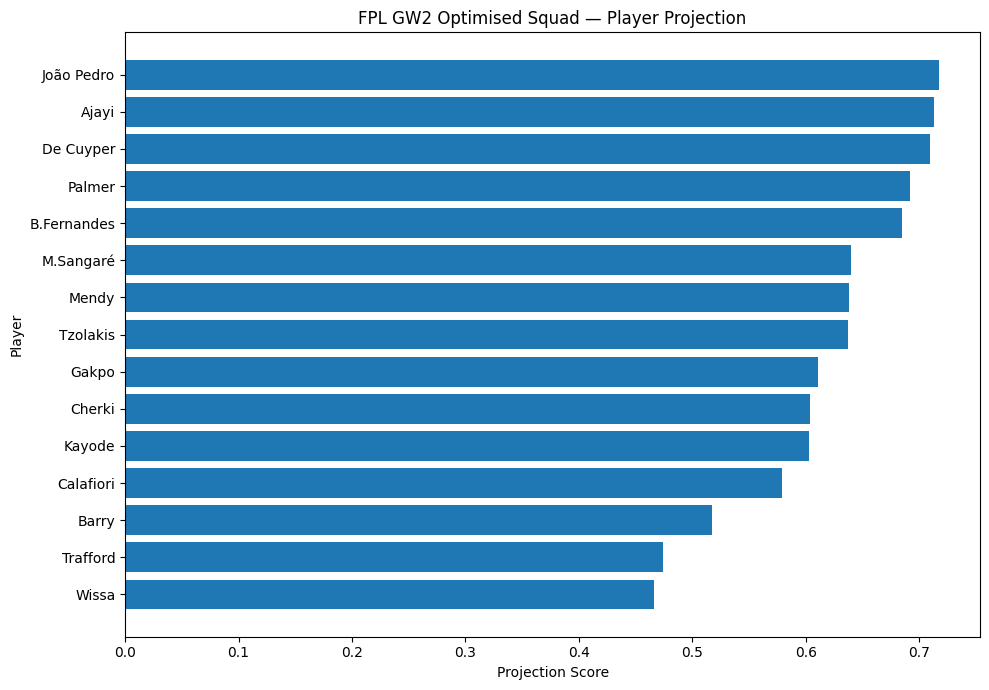

In [ ]:
# ============================================================
# FINAL SQUAD VISUALISATION
# ============================================================

plot_df = final_squad.copy()

plot_df = (
    plot_df
    .sort_values("projection_score", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_df["web_name"],
    plot_df["projection_score"]
)

plt.xlabel("Projection Score")
plt.ylabel("Player")
plt.title(
    f"FPL GW{CURRENT_GW} Optimised Squad — Player Projection"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# FINAL DASHBOARD
# ============================================================

print("=" * 70)
print(f"⚽ FPL MULTI-AGENT SQUAD PICKER — GAMEWEEK {CURRENT_GW}")
print("=" * 70)

print(f"\n💰 Squad Cost: £{total_cost:.1f}m")
print(f"💵 Remaining: £{remaining_budget:.1f}m")

print("\n👕 STARTING XI")
print("-" * 40)

for _, row in (
    starting_xi
    .sort_values(["position", "expected_start_score"], ascending=[True, False])
    .iterrows()
):
    print(
        f"{row['position']:>3} | "
        f"{row['web_name']:<20} | "
        f"{row['team_name']:<18} | "
        f"£{row['price']:.1f}m"
    )

print("\n🪑 BENCH")
print("-" * 40)

bench = final_squad[
    ~final_squad["id"].isin(
        starting_xi["id"]
    )
]

for i, (_, row) in enumerate(
    bench.iterrows(),
    start=1
):
    print(
        f"{i}. {row['web_name']} "
        f"({row['team_name']})"
    )

print("\n👑 CAPTAIN")
print("-", 40)
print(captain["web_name"])

print("\n🎖️ VICE-CAPTAIN")
print("-", 40)
print(vice_captain["web_name"])

print("\n" + "=" * 70)

⚽ FPL MULTI-AGENT SQUAD PICKER — GAMEWEEK 2

💰 Squad Cost: £93.9m
💵 Remaining: £6.1m

👕 STARTING XI
----------------------------------------
DEF | Ajayi                | Hull City          | £4.1m
DEF | De Cuyper            | Brighton           | £4.7m
DEF | Mendy                | Hull City          | £4.0m
DEF | Kayode               | Brentford          | £4.6m
FWD | João Pedro           | Chelsea            | £7.7m
 GK | Tzolakis             | Hull City          | £4.6m
MID | Palmer               | Chelsea            | £9.6m
MID | B.Fernandes          | Man Utd            | £12.0m
MID | M.Sangaré            | Brentford          | £5.7m
MID | Gakpo                | Liverpool          | £7.0m
MID | Cherki               | Man City           | £7.7m

🪑 BENCH
----------------------------------------
1. Trafford (Leeds)
2. Calafiori (Arsenal)
3. Barry (Everton)
4. Wissa (Newcastle)

👑 CAPTAIN
- 40
B.Fernandes

🎖️ VICE-CAPTAIN
- 40
João Pedro

